
## Basic analsysis 
A simplest series to start with is the set of Cu—Ni alloy samples.
We suggest that you start with the pure copper data.
Can you locate and index the observed peaks?
Can you fit them?
What function works best to fit the peaks?
Can you identify the correct Bravais lattice?
How well can you determine the lattice parameter? (Many tables only list two or three digits, you should be able to do much better)
## Deeper analysis.
What happens to the diffraction pattern as nickel is alloyed with copper?
What can you say about the crystal structure?
What can you say about the lattice parameter?
## The Lead—Tin system.
This system is more complex, not least because tin adopts a tetragonal structure.
What can you say about the Lead—Tin alloy system?
How does it differ from the Copper—Nickel system?
## The Mystery Samples.
There are samples of several different elements available
Can you identify the structures?
How well can you determine the lattice parameters?
Can you identify the elements?
## Cu3Au.
This is a more interesting challenge.
The two Cu3Au samples were taken from pieces of the same ingot so they have precisely the same
composition, however they were subjected to different heat treatments.
What can you say about the differences between the two samples based on their diffraction patterns?


## notes
incorperate error / error bars
fix graphs (grid , legends)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.signal import find_peaks
import spinmob
import mcphysics

#Python Libs
import os

In [ ]:

badfiles=["Cu_08-09-26.UXD"]

wavelen = 1.5406  # Angstrom, Cu K_alpha
n = 1


samples = {
    'Cu': {},
    'Ni': {},
    'Sn': {},
    'Pb': {},
    'A' : {},
    'B': {}
}

for sample in samples:
    samples[sample]['files'] = [file for file in os.listdir('XRD_data') if file not in badfiles and file.split('_')[0]==sample]
    print(samples[sample]['files'])

    samples[sample][file]['twotheta']=[]
    samples[sample][file]['intensity']=[]
    





['Cu_10-09-26_2.UXD', 'Cu_10-09-26.UXD']
['Ni_10-09-26_2.UXD', 'Ni_08-09-26.UXD', 'Ni_10-09-26.UXD']
['Sn_15-09-26.UXD']
['Pb_15-09-26.UXD']
['A_17-09-26_2.UXD', 'A_17-09-26.UXD']
['B_17-09-26.UXD', 'B_17-09-26_2.UXD']


## Locating and indexing the observed peaks


Ni_08-09-26
2θ (°)       Intensity       d (Å)
----------------------------------------
  44.45           2963       2.03651
  51.85           1018       1.76192
  76.40            445       1.24562
  92.90            366       1.06281
  98.35            138       1.01796

Ni_10-09-26
2θ (°)       Intensity       d (Å)
----------------------------------------
  44.45           2607       2.03651
  51.80            912       1.76350
  76.40            399       1.24562
  92.95            305       1.06237
  98.35            125       1.01796

Ni_10-09-26_2
2θ (°)       Intensity       d (Å)
----------------------------------------
  44.45           2524       2.03651
  51.80            905       1.76350
  76.40            420       1.24562
  92.90            314       1.06281
  98.45            124       1.01719

Cu_10-09-26
2θ (°)       Intensity       d (Å)
----------------------------------------
  43.35           3015       2.08560
  50.50            995       1.80581
  74.20      

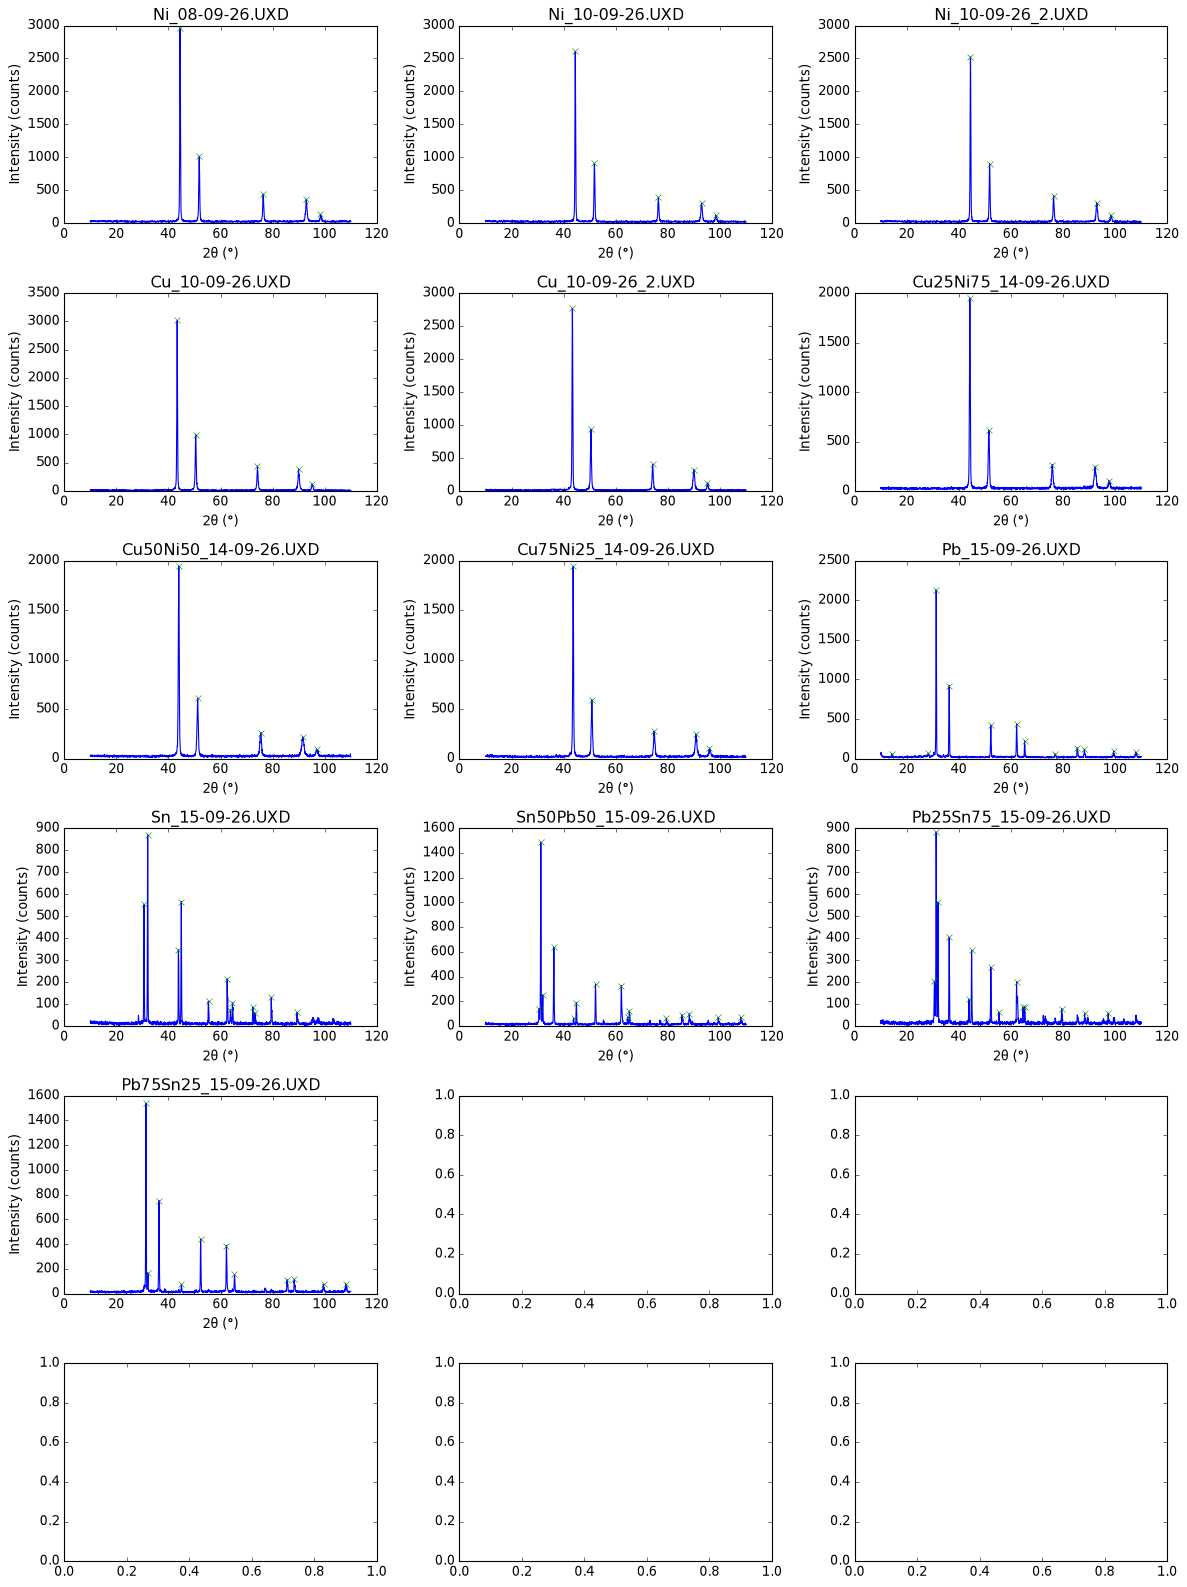

In [30]:
# List of files
files = [
    "XRD_data/Ni_08-09-26.UXD",
    "XRD_data/Ni_10-09-26.UXD",
    "XRD_data/Ni_10-09-26_2.UXD",
    "XRD_data/Cu_10-09-26.UXD",
    "XRD_data/Cu_10-09-26_2.UXD",
    "XRD_data/Cu25Ni75_14-09-26.UXD",
    "XRD_data/Cu50Ni50_14-09-26.UXD",
    "XRD_data/Cu75Ni25_14-09-26.UXD",
    "XRD_data/Pb_15-09-26.UXD",
    "XRD_data/Sn_15-09-26.UXD",
    "XRD_data/Sn50Pb50_15-09-26.UXD",
    "XRD_data/Pb25Sn75_15-09-26.UXD",
    "XRD_data/Pb75Sn25_15-09-26.UXD"
]

fig, axes = plt.subplots(6, 3, figsize=(15, 20))

axes = axes.flatten()

peak_angles = {}
peak_intensities = {}
peak_d = {}

# Bragg's law
wavelength = 1.5406  # Angstrom, Cu K_alpha
n = 1

for i, file in enumerate(files):

    # Load data
    data = np.loadtxt(file)

    twotheta = data[:, 0]
    intensity = data[:, 1]

    # Find peaks
    peaks, _ = find_peaks(intensity, prominence=50)

    # Store peak angles and intensities
    name = file.split("/")[-1].replace(".UXD", "")
    peak_angles[name] = twotheta[peaks]
    peak_intensities[name] = intensity[peaks]

    theta = np.radians(twotheta[peaks] / 2)
    peak_d[name] = wavelength / (2 * np.sin(theta))

    

    # Print peaks
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("2θ (°)       Intensity       d (Å)")
    print("----------------------------------------")

    for angle, I in zip(twotheta[peaks], intensity[peaks]):

        theta = np.radians(angle / 2    )
        d = wavelength / (2 * np.sin(theta))

        print(f"{angle:7.2f}       {I:8.0f}       {d:7.5f}")

    # Plot
    axes[i].plot(twotheta, intensity)

    # Labels
    axes[i].set_xlabel("2θ (°)")
    axes[i].set_ylabel("Intensity (counts)")
    axes[i].set_title(file.split("/")[-1])

    # Show peaks
    axes[i].plot(twotheta[peaks], intensity[peaks], "x")
    
# Make spacing nicer
plt.tight_layout()

plt.grid

plt.show()

## Fitting the observed peaks and identifying the Bravais lattice (with more than 2 digit precision)

In [28]:
for name in peak_d:

    d = peak_d[name]

    # Calculate 1/d^2
    Q = 1 / d**2

    # Normalize to the first peak
    ratio = Q / Q[0]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Peak   d (Å)       1/d²        Ratio")
    print("-------------------------------------------")

    for i in range(len(d)):
        print(f"{i+1:4d}   {d[i]:8.5f}   {Q[i]:8.4f}   {ratio[i]:8.4f}")

    # Compare with common cubic series
    print("\nPossible cubic series:")

    # Simple cubic
    SC = np.array([1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12])

    # BCC: h+k+l even
    BCC = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])

    # FCC: h,k,l all odd or all even
    FCC = np.array([3, 4, 8, 11, 12, 16, 19, 20, 24, 27])

    # Normalize each series to its first value
    series = {
        "SC": SC / SC[0],
        "BCC": BCC / BCC[0],
        "FCC": FCC / FCC[0]
    }

    for crystal, values in series.items():

        # Only compare as many values as we have peaks
        n = min(len(ratio), len(values))

        error = np.mean((ratio[:n] - values[:n])**2)

        print(f"{crystal}: {values[:n]}   error = {error:.5f}")


Cu_10-09-26_2
Peak   d (Å)       1/d²        Ratio
-------------------------------------------
   1    2.08560     0.2299     1.0000
   2    1.80581     0.3067     1.3339
   3    1.27774     0.6125     2.6643
   4    1.08984     0.8419     3.6621
   5    1.04312     0.9190     3.9975

Possible cubic series:
SC: [1. 2. 3. 4. 5.]   error = 0.33510
BCC: [1. 2. 3. 4. 5.]   error = 0.33510
FCC: [1.         1.33333333 2.66666667 3.66666667 4.        ]   error = 0.00001

Cu25Ni75_14-09-26
Peak   d (Å)       1/d²        Ratio
-------------------------------------------
   1    2.04525     0.2391     1.0000
   2    1.77467     0.3175     1.3282
   3    1.25187     0.6381     2.6691
   4    1.06725     0.8779     3.6725
   5    1.02299     0.9556     3.9972

Possible cubic series:
SC: [1. 2. 3. 4. 5.]   error = 0.33475
BCC: [1. 2. 3. 4. 5.]   error = 0.33475
FCC: [1.         1.33333333 2.66666667 3.66666667 4.        ]   error = 0.00001

Ni_10-09-26_2
Peak   d (Å)       1/d²        Ratio
------